# Concrete Compressive Strength 분석 및 모델 비교
**TabPFN Regressor vs LightGBM (Default, Tuned)**

이 노트북은 콘크리트 압축 강도(Concrete Compressive Strength) 데이터셋을 활용하여,
사전 학습된 Transformer 기반의 Zero-shot 모델인 **TabPFN**과 대표적인 GBDT 모델인 **LightGBM**의 성능을 비교합니다.

In [ ]:
# -*- coding: utf-8 -*-
"""
Concrete Compressive Strength 분석 및 모델 비교
TabPFN vs LightGBM (Default, Tuned)
"""

import sys
import os

# 윈도우 사용자명이 한글일 때 multiprocessing의 임시 경로 인코딩 에러 방지
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

project_temp = os.path.abspath(os.path.join(current_dir, "..", "results", "temp"))
os.makedirs(project_temp, exist_ok=True)
os.environ["TEMP"] = project_temp
os.environ["TMP"] = project_temp
os.environ["TMPDIR"] = project_temp
os.environ["JOBLIB_TEMP_FOLDER"] = project_temp
os.environ["LOKY_TEMP_FOLDER"] = project_temp

# API 토큰 설정 (사용자 입력된 값 연동)
os.environ["TABPFN_TOKEN"] = os.getenv("TABPFN_TOKEN", "")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN", "")

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8', errors='replace')


### 라이브러리 임포트


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ML
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import optuna

# TabPFN
import torch
from tabpfn import TabPFNRegressor

# SHAP
import shap

print("✅ 라이브러리 임포트 완료")


✅ 라이브러리 임포트 완료


### 환경 확인


In [3]:
print("=" * 60)
print("📦 패키지 버전 및 GPU 상태 확인")
print("=" * 60)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  PyTorch    : {torch.__version__}")
print(f"  CUDA 사용  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU        : {torch.cuda.get_device_name(0)}")
print(f"  LightGBM   : {lgb.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print("=" * 60)


📦 패키지 버전 및 GPU 상태 확인
  Python     : 3.12.10
  PyTorch    : 2.7.1+cu118
  CUDA 사용  : True
  GPU        : NVIDIA GeForce RTX 2070 SUPER
  LightGBM   : 4.6.0
  scikit-learn: 1.8.0
  pandas     : 3.0.3
  numpy      : 2.4.6


### 시각화 설정 (한글 폰트 대응 포함)


In [4]:
# 윈도우 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# 모델 색상 팔레트
COLORS = {
    'tabpfn': '#6C5CE7',      # 보라 (TabPFN)
    'lgbm_default': '#00B894', # 초록 (LightGBM Default)
    'lgbm_tuned': '#E17055',   # 주황 (LightGBM Tuned)
}

MODEL_NAMES = {
    'tabpfn': 'TabPFN (Zero-shot)',
    'lgbm_default': 'LightGBM (Default)',
    'lgbm_tuned': 'LightGBM (Tuned)',
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 결과 저장 디렉토리
RESULTS_DIR = os.path.join('..', 'results', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ 시각화 및 결과 저장 설정 완료")


✅ 시각화 및 결과 저장 설정 완료


### 데이터 로드


In [5]:
DATA_PATH = os.path.join('..', 'data', 'Concrete_Data.csv')
print(f"📁 데이터 로드 경로: {DATA_PATH}")

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Concrete_Data 로드 완료")
else:
    # 절대 경로 체크 (디렉토리 구조 대응)
    DATA_PATH_ALT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..', 'data', 'Concrete_Data.csv'))
    if os.path.exists(DATA_PATH_ALT):
        df = pd.read_csv(DATA_PATH_ALT)
        print(f"✅ Concrete_Data 로드 완료 (대체 경로)")
    else:
        raise FileNotFoundError(f"❌ '{DATA_PATH}' 또는 '{DATA_PATH_ALT}'에 파일이 없습니다.")


📁 데이터 로드 경로: ..\data\Concrete_Data.csv
✅ Concrete_Data 로드 완료


### 기본 정보 확인


In [6]:
print("=" * 60)
print("📊 데이터 기본 정보")
print("=" * 60)
print(f"  Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  메모리 사용 : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("📌 컬럼 목록 및 데이터 타입:")
print(df.dtypes.to_string())
print()
print("📌 처음 5행 데이터:")
print(df.head().to_string())


📊 데이터 기본 정보
  Shape      : 1,030 rows × 9 columns
  메모리 사용 : 0.07 MB

📌 컬럼 목록 및 데이터 타입:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64

📌 처음 5행 데이터:
   Cement (component 1)(kg in a m^3 mixture)  Blast Furnace Slag (component 2)(kg in a m^3 mixture)  Fly Ash (component 3)(kg in a m^3 mixture)  Water  (component 4)(kg in a m^3 mixture)  Superplasticizer (component 5)(kg in a m^3 mixture)  Coarse Aggregate  (component 6)(kg in a m^3 mixture)  Fine Aggregate (co

### 기술 통계량 및 결측치 확인


In [7]:
print("=" * 60)
print("📊 기술 통계량 (Descriptive Statistics)")
print("=" * 60)
print(df.describe().round(2).to_string())
print()
print("📌 결측치 현황:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ 결측치 없음")
else:
    print(missing[missing > 0])

print(f"\n📌 중복 행 개수: {df.duplicated().sum()}")


📊 기술 통계량 (Descriptive Statistics)
       Cement (component 1)(kg in a m^3 mixture)  Blast Furnace Slag (component 2)(kg in a m^3 mixture)  Fly Ash (component 3)(kg in a m^3 mixture)  Water  (component 4)(kg in a m^3 mixture)  Superplasticizer (component 5)(kg in a m^3 mixture)  Coarse Aggregate  (component 6)(kg in a m^3 mixture)  Fine Aggregate (component 7)(kg in a m^3 mixture)  Age (day)  Concrete compressive strength(MPa, megapascals) 
count                                    1030.00                                                1030.00                                     1030.00                                    1030.00                                              1030.00                                               1030.00                                            1030.00    1030.00                                           1030.00
mean                                      281.17                                                  73.90                                       54.1

### 타겟 및 피처 설정


In [8]:
# 콘크리트 압축 강도 타겟 변수명 자동 매칭 또는 명시적 설정
TARGET = 'Concrete compressive strength(MPa, megapascals) '
if TARGET not in df.columns:
    # 유사한 이름 매칭
    candidates = [c for c in df.columns if 'strength' in c.lower()]
    if candidates:
        TARGET = candidates[0]
    else:
        TARGET = df.columns[-1]

feature_cols = [c for c in df.columns if c != TARGET]

print(f"✅ 설정된 타겟 변수: '{TARGET}'")
print(f"✅ 설정된 피처 ({len(feature_cols)}개): {feature_cols}")


✅ 설정된 타겟 변수: 'Concrete compressive strength(MPa, megapascals) '
✅ 설정된 피처 (8개): ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)']


### 시각화 - 타겟 변수 분포


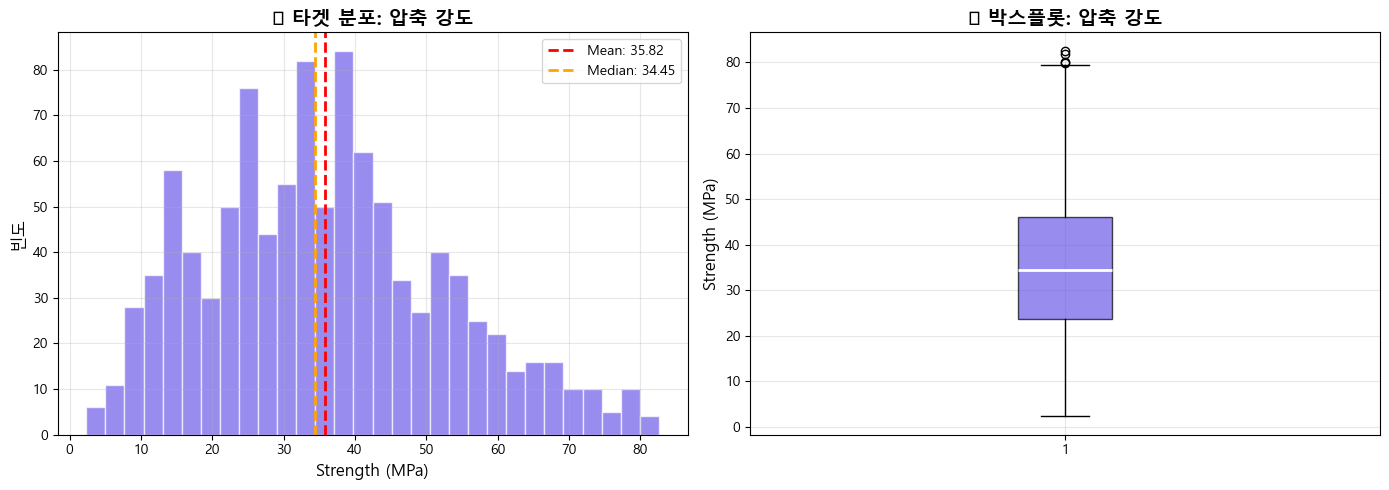

💾 저장: results/figures/01_target_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df[TARGET], bins=30, color='#6C5CE7', alpha=0.7, edgecolor='white')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df[TARGET].median():.2f}')
axes[0].set_title(f'📊 타겟 분포: 압축 강도', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Strength (MPa)')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 박스플롯
axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#6C5CE7', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title(f'📦 박스플롯: 압축 강도', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Strength (MPa)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '01_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/01_target_distribution.png")


### 시각화 - 상관관계 히트맵


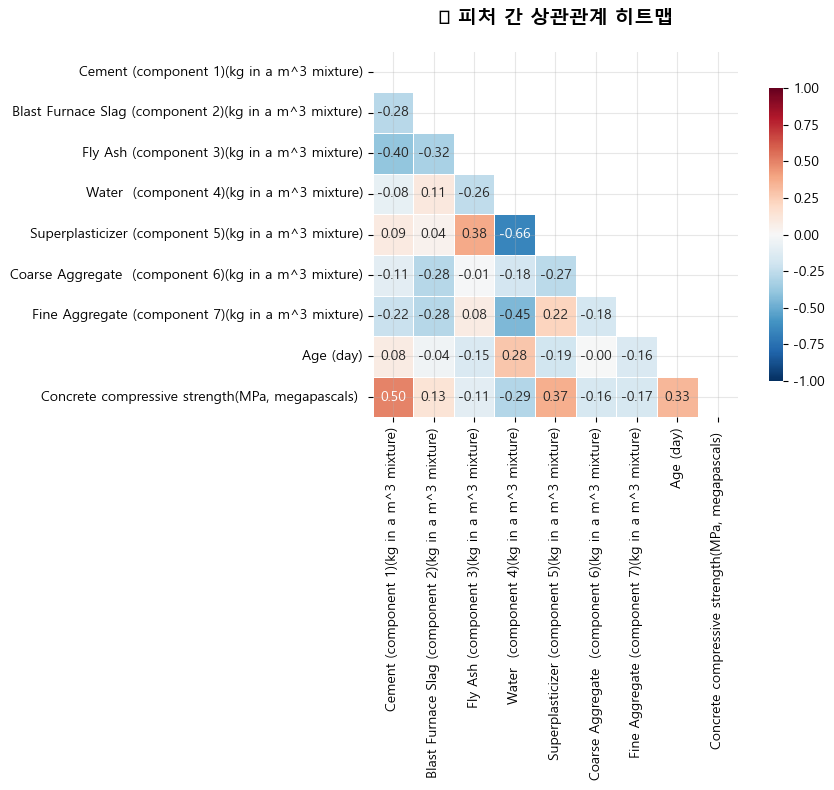

💾 저장: results/figures/02_correlation_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔥 피처 간 상관관계 히트맵', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/02_correlation_heatmap.png")


### 시각화 - 주요 피처 vs 타겟 산점도


📌 타겟과의 상관계수 순위:
  - Cement (component 1)(kg in a m^3 mixture): 0.4978
  - Superplasticizer (component 5)(kg in a m^3 mixture): 0.3661
  - Age (day): 0.3289
  - Water  (component 4)(kg in a m^3 mixture): -0.2896
  - Fine Aggregate (component 7)(kg in a m^3 mixture): -0.1672
  - Coarse Aggregate  (component 6)(kg in a m^3 mixture): -0.1649
  - Blast Furnace Slag (component 2)(kg in a m^3 mixture): 0.1348
  - Fly Ash (component 3)(kg in a m^3 mixture): -0.1058


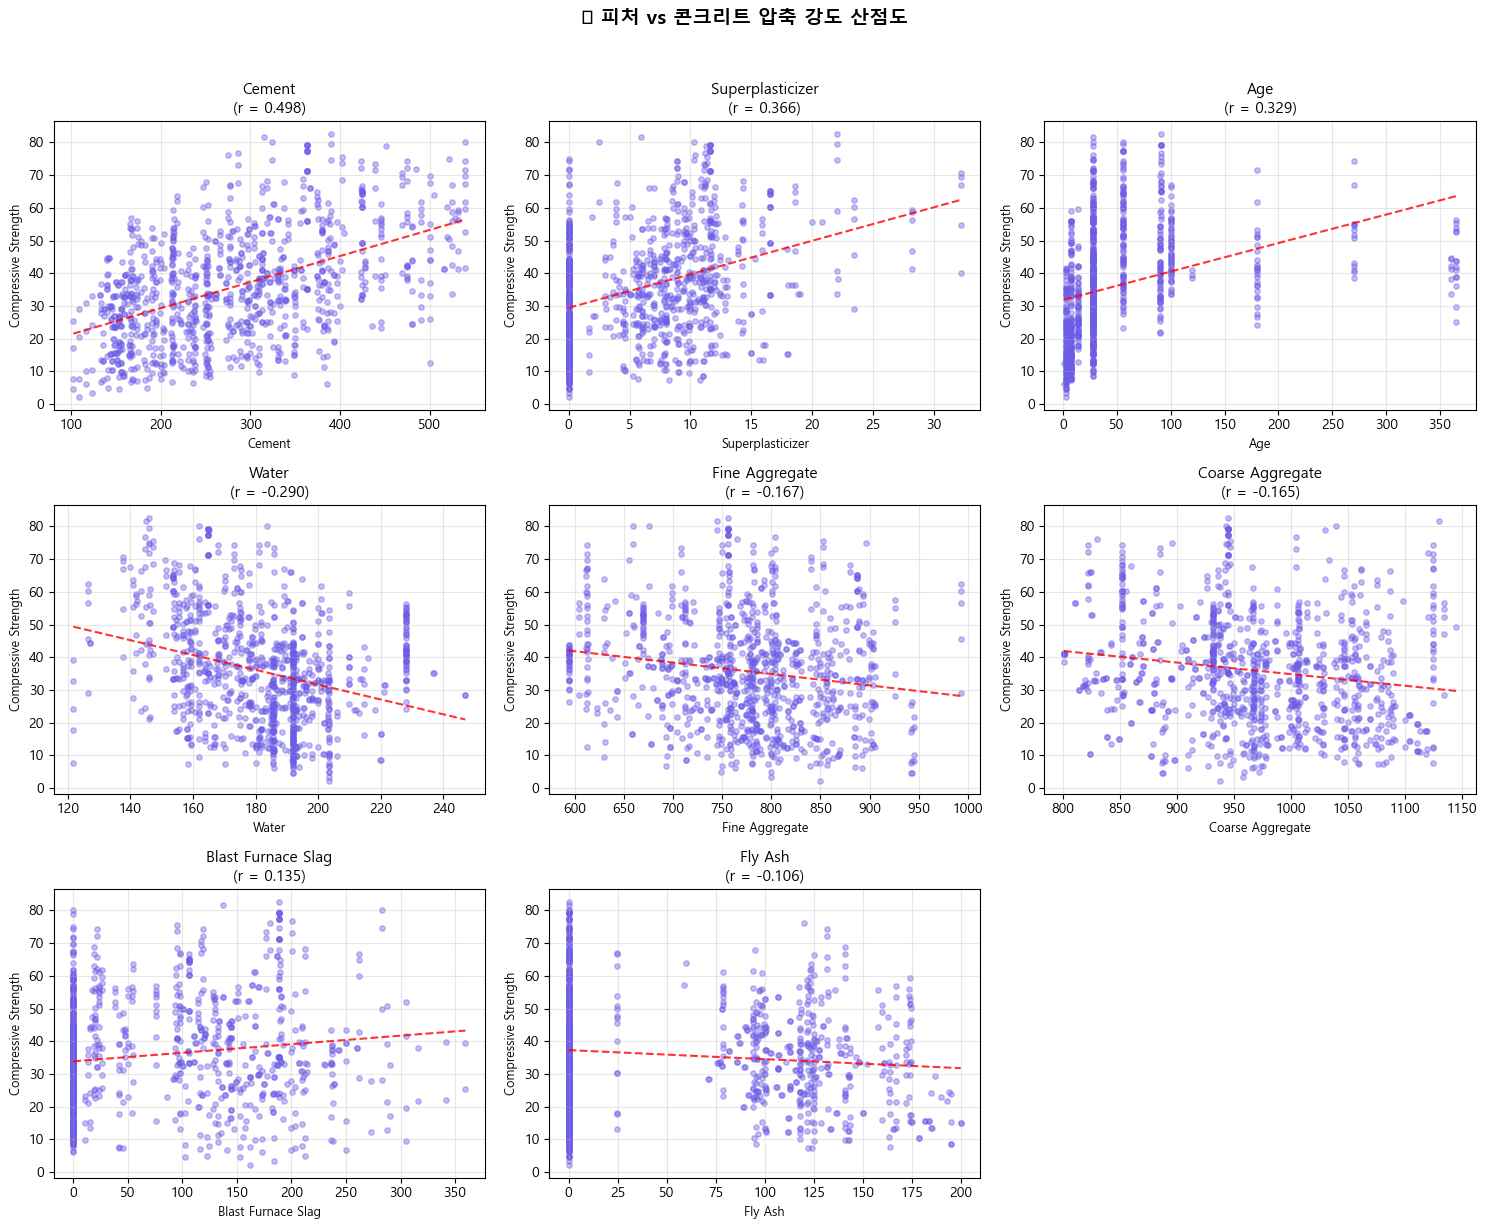

💾 저장: results/figures/03_feature_vs_target.png


In [11]:
# 타겟과 상관관계 절대값이 높은 순으로 상위 피처 선정
target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top_features = target_corr.index.tolist()

print("📌 타겟과의 상관계수 순위:")
for col in top_features:
    print(f"  - {col}: {corr_matrix[TARGET][col]:.4f}")

n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    ax.scatter(df[feat], df[TARGET], alpha=0.4, s=15, color='#6C5CE7')
    
    # 1차 선형 추세선 추가
    z = np.polyfit(df[feat], df[TARGET], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.8)
    
    corr_val = corr_matrix[TARGET][feat]
    # 긴 피처 이름 가독성을 위해 축약 시도
    short_feat = feat.split('(')[0].strip()
    ax.set_title(f'{short_feat}\n(r = {corr_val:.3f})', fontsize=11)
    ax.set_xlabel(short_feat, fontsize=9)
    ax.set_ylabel('Compressive Strength', fontsize=9)

# 빈 서브플롯 숨기기
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('📈 피처 vs 콘크리트 압축 강도 산점도', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_feature_vs_target.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/03_feature_vs_target.png")


### Train / Test 분할 (80:20)


In [12]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"✅ 학습 데이터 크기  : {X_train.shape[0]:,} rows")
print(f"✅ 테스트 데이터 크기: {X_test.shape[0]:,} rows")


✅ 학습 데이터 크기  : 824 rows
✅ 테스트 데이터 크기: 206 rows


### 모델 학습 - TabPFN (Zero-shot)


In [13]:
print("=" * 60)
print("🤖 TabPFN Regressor 학습 및 추론 시작")
print("=" * 60)

# GPU가 사용 가능하면 cuda 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용 장비: {device}")

model_tabpfn = TabPFNRegressor(device=device)

# 학습 시간 (핏팅)
start_time = time.time()
model_tabpfn.fit(X_train, y_train)
time_fit_tabpfn = time.time() - start_time

# 추론 시간 (평균 예측)
start_time = time.time()
y_pred_tabpfn = model_tabpfn.predict(X_test)
time_pred_tabpfn = time.time() - start_time

print(f"✅ TabPFN 완료 (학습: {time_fit_tabpfn:.3f}초, 추론: {time_pred_tabpfn:.3f}초)")


🤖 TabPFN Regressor 학습 및 추론 시작
사용 장비: cuda


✅ TabPFN 완료 (학습: 1.138초, 추론: 1.176초)


### TabPFN 분위수 예측 (Quantile Prediction)


In [14]:
print("🔮 TabPFN 분위수 예측 진행")
try:
    # 0.1, 0.5, 0.9 분위수 예측
    y_quantiles_tabpfn = model_tabpfn.predict(X_test, output_type='quantiles')
    if isinstance(y_quantiles_tabpfn, list):
        y_quantiles_tabpfn = np.array(y_quantiles_tabpfn)
    has_quantiles = True
    print(f"  ✅ 분위수 예측 성공 (Shape: {y_quantiles_tabpfn.shape})")
except Exception as e:
    has_quantiles = False
    print(f"  ⚠️ 분위수 예측 에러: {e}")


🔮 TabPFN 분위수 예측 진행


  ✅ 분위수 예측 성공 (Shape: (9, 206))


### 모델 학습 - LightGBM (Default)


In [15]:
print("=" * 60)
print("🌲 LightGBM (Default) 학습 및 추론 시작")
print("=" * 60)

model_lgbm_default = lgb.LGBMRegressor(
    random_state=RANDOM_STATE,
    verbose=-1
)

start_time = time.time()
model_lgbm_default.fit(X_train, y_train)
time_fit_lgbm_default = time.time() - start_time

start_time = time.time()
y_pred_lgbm_default = model_lgbm_default.predict(X_test)
time_pred_lgbm_default = time.time() - start_time

print(f"✅ LightGBM Default 완료 (학습: {time_fit_lgbm_default:.3f}초, 추론: {time_pred_lgbm_default:.3f}초)")


🌲 LightGBM (Default) 학습 및 추론 시작


✅ LightGBM Default 완료 (학습: 1.465초, 추론: 0.001초)


### Optuna 하이퍼파라미터 최적화 (LightGBM)


In [16]:
print("=" * 60)
print("🎯 LightGBM (Tuned) - Optuna 튜닝 시작 (50 trials)")
print("=" * 60)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return scores.mean()

# 튜닝 시간 측정
start_time_tuning = time.time()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50)
time_tuning = time.time() - start_time_tuning

print(f"✅ 최적화 완료 (소요 시간: {time_tuning:.2f}초)")
print(f"  최적 CV RMSE (neg): {study.best_value:.6f}")
print("📌 최적 파라미터:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")


🎯 LightGBM (Tuned) - Optuna 튜닝 시작 (50 trials)


✅ 최적화 완료 (소요 시간: 39.00초)
  최적 CV RMSE (neg): -4.548223
📌 최적 파라미터:
  - n_estimators: 371
  - max_depth: 9
  - learning_rate: 0.14789739786177775
  - num_leaves: 215
  - min_child_samples: 36
  - subsample: 0.6983389156437046
  - colsample_bytree: 0.6975223575019218
  - reg_alpha: 0.030573368493131352
  - reg_lambda: 9.332470766350168e-08


### 최적 파라미터 재학습 - LightGBM (Tuned)


In [17]:
best_params = study.best_params.copy()
best_params['random_state'] = RANDOM_STATE
best_params['verbose'] = -1

model_lgbm_tuned = lgb.LGBMRegressor(**best_params)

start_time = time.time()
model_lgbm_tuned.fit(X_train, y_train)
time_fit_lgbm_tuned = time.time() - start_time

start_time = time.time()
y_pred_lgbm_tuned = model_lgbm_tuned.predict(X_test)
time_pred_lgbm_tuned = time.time() - start_time

print(f"✅ LightGBM Tuned 완료 (학습: {time_fit_lgbm_tuned:.3f}초, 추론: {time_pred_lgbm_tuned:.3f}초)")


✅ LightGBM Tuned 완료 (학습: 0.122초, 추론: 0.003초)


### 성능 평가 지표 계산 및 비교


In [18]:
def get_regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # MAPE 계산 (실제값 0 제외)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }

results = []
results.append(get_regression_metrics(y_test, y_pred_tabpfn, MODEL_NAMES['tabpfn']))
results.append(get_regression_metrics(y_test, y_pred_lgbm_default, MODEL_NAMES['lgbm_default']))
results.append(get_regression_metrics(y_test, y_pred_lgbm_tuned, MODEL_NAMES['lgbm_tuned']))

df_results = pd.DataFrame(results).set_index('Model')

print("=" * 70)
print("📊 모델 성능 비교 (테스트 데이터 셋)")
print("=" * 70)
print(df_results.round(4).to_string())
print()

best_r2_model = df_results['R²'].idxmax()
best_rmse_model = df_results['RMSE'].idxmin()
print(f"🏆 Best R²   : {best_r2_model} ({df_results.loc[best_r2_model, 'R²']:.4f})")
print(f"🏆 Best RMSE : {best_rmse_model} ({df_results.loc[best_rmse_model, 'RMSE']:.4f})")


📊 모델 성능 비교 (테스트 데이터 셋)
                       MAE    RMSE      R²  MAPE (%)
Model                                               
TabPFN (Zero-shot)  2.3218  3.9292  0.9401    7.4760
LightGBM (Default)  3.1640  4.6902  0.9146    9.8496
LightGBM (Tuned)    2.9687  4.3202  0.9276    9.4983

🏆 Best R²   : TabPFN (Zero-shot) (0.9401)
🏆 Best RMSE : TabPFN (Zero-shot) (3.9292)


### 5-Fold Cross-Validation 상세 비교


In [19]:
print("=" * 60)
print("📊 5-Fold Cross-Validation 비교 검증")
print("=" * 60)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

# 1. TabPFN CV
print("🤖 TabPFN CV 수행 중...")
tabpfn_cv = TabPFNRegressor(device=device)
scores_tabpfn = cross_val_score(tabpfn_cv, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
cv_results['tabpfn'] = -scores_tabpfn
print(f"  - TabPFN RMSE: {-scores_tabpfn.mean():.4f} ± {scores_tabpfn.std():.4f}")

# 2. LightGBM Default CV
print("🌲 LightGBM (Default) CV 수행 중...")
lgbm_cv_d = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
scores_lgbm_d = cross_val_score(lgbm_cv_d, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['lgbm_default'] = -scores_lgbm_d
print(f"  - LGBM Default RMSE: {-scores_lgbm_d.mean():.4f} ± {scores_lgbm_d.std():.4f}")

# 3. LightGBM Tuned CV
print("🎯 LightGBM (Tuned) CV 수행 중...")
lgbm_cv_t = lgb.LGBMRegressor(**best_params)
scores_lgbm_t = cross_val_score(lgbm_cv_t, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_results['lgbm_tuned'] = -scores_lgbm_t
print(f"  - LGBM Tuned RMSE: {-scores_lgbm_t.mean():.4f} ± {scores_lgbm_t.std():.4f}")


📊 5-Fold Cross-Validation 비교 검증
🤖 TabPFN CV 수행 중...


  - TabPFN RMSE: 3.8426 ± 0.3482
🌲 LightGBM (Default) CV 수행 중...
  - LGBM Default RMSE: 4.6053 ± 0.5002
🎯 LightGBM (Tuned) CV 수행 중...


  - LGBM Tuned RMSE: 4.1765 ± 0.3525


### 시각화 - 5-Fold CV RMSE 비교 박스플롯


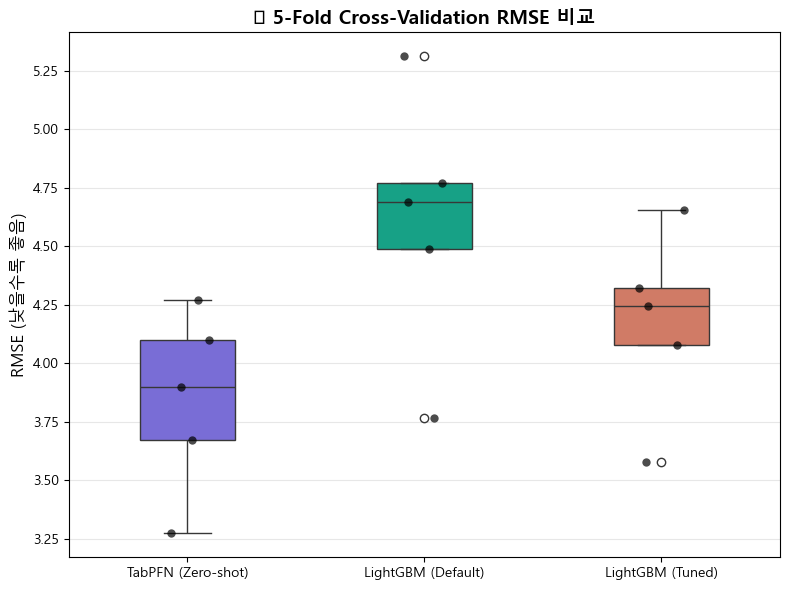

💾 저장: results/figures/04_cv_comparison.png


In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

cv_data = []
for k in ['tabpfn', 'lgbm_default', 'lgbm_tuned']:
    for val in cv_results[k]:
        cv_data.append({'Model': MODEL_NAMES[k], 'RMSE': val})
df_cv = pd.DataFrame(cv_data)

sns.boxplot(data=df_cv, x='Model', y='RMSE', palette=[COLORS['tabpfn'], COLORS['lgbm_default'], COLORS['lgbm_tuned']], width=0.4, ax=ax)
sns.stripplot(data=df_cv, x='Model', y='RMSE', color='black', size=6, alpha=0.7, ax=ax)

ax.set_title('📊 5-Fold Cross-Validation RMSE 비교', fontsize=14, fontweight='bold')
ax.set_ylabel('RMSE (낮을수록 좋음)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_cv_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/04_cv_comparison.png")


### 시각화 - 예측값 vs 실제값 산점도


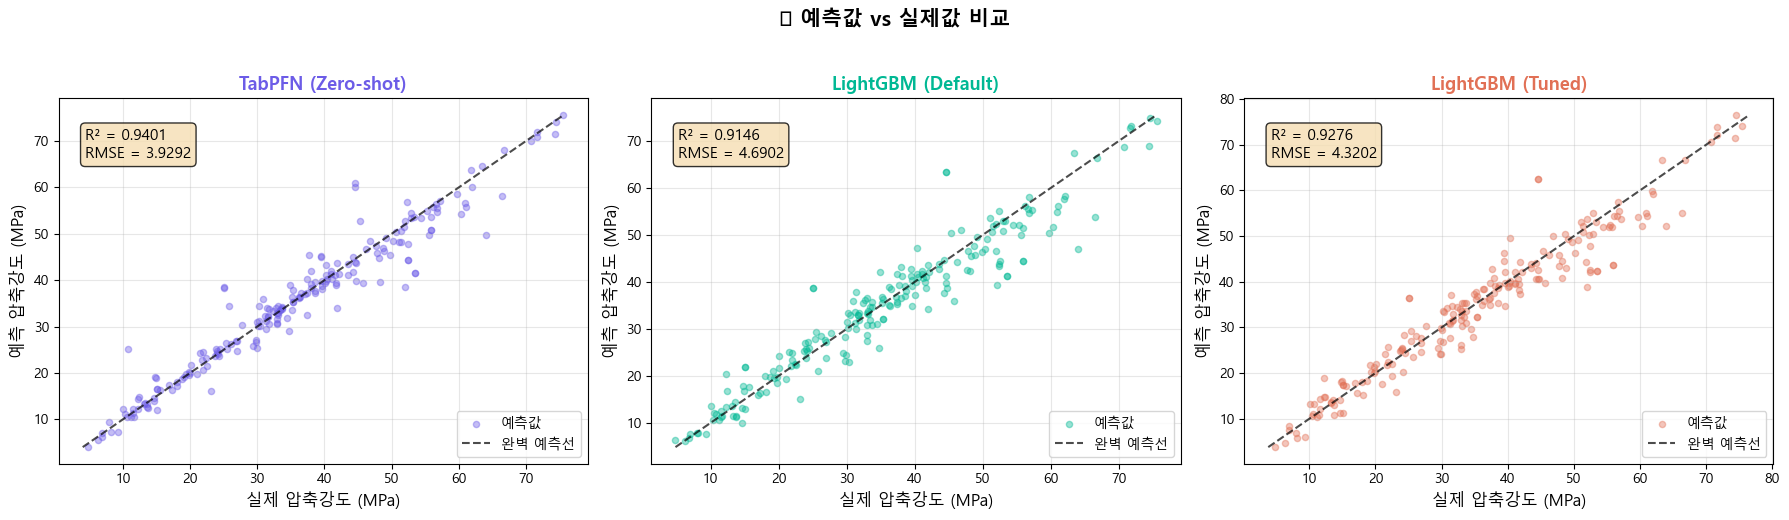

💾 저장: results/figures/05_pred_vs_actual.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_pred_data = [
    ('tabpfn', MODEL_NAMES['tabpfn'], y_pred_tabpfn),
    ('lgbm_default', MODEL_NAMES['lgbm_default'], y_pred_lgbm_default),
    ('lgbm_tuned', MODEL_NAMES['lgbm_tuned'], y_pred_lgbm_tuned),
]

for ax, (key, name, y_pred) in zip(axes, models_pred_data):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=COLORS[key], label='예측값')
    
    # 완벽 예측 대각선
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.7, label='완벽 예측선')
    
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.text(0.05, 0.92, f'R² = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title(name, fontsize=13, fontweight='bold', color=COLORS[key])
    ax.set_xlabel('실제 압축강도 (MPa)')
    ax.set_ylabel('예측 압축강도 (MPa)')
    ax.legend(loc='lower right')

fig.suptitle('🎯 예측값 vs 실제값 비교', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/05_pred_vs_actual.png")


### 시각화 - 잔차 분포 비교


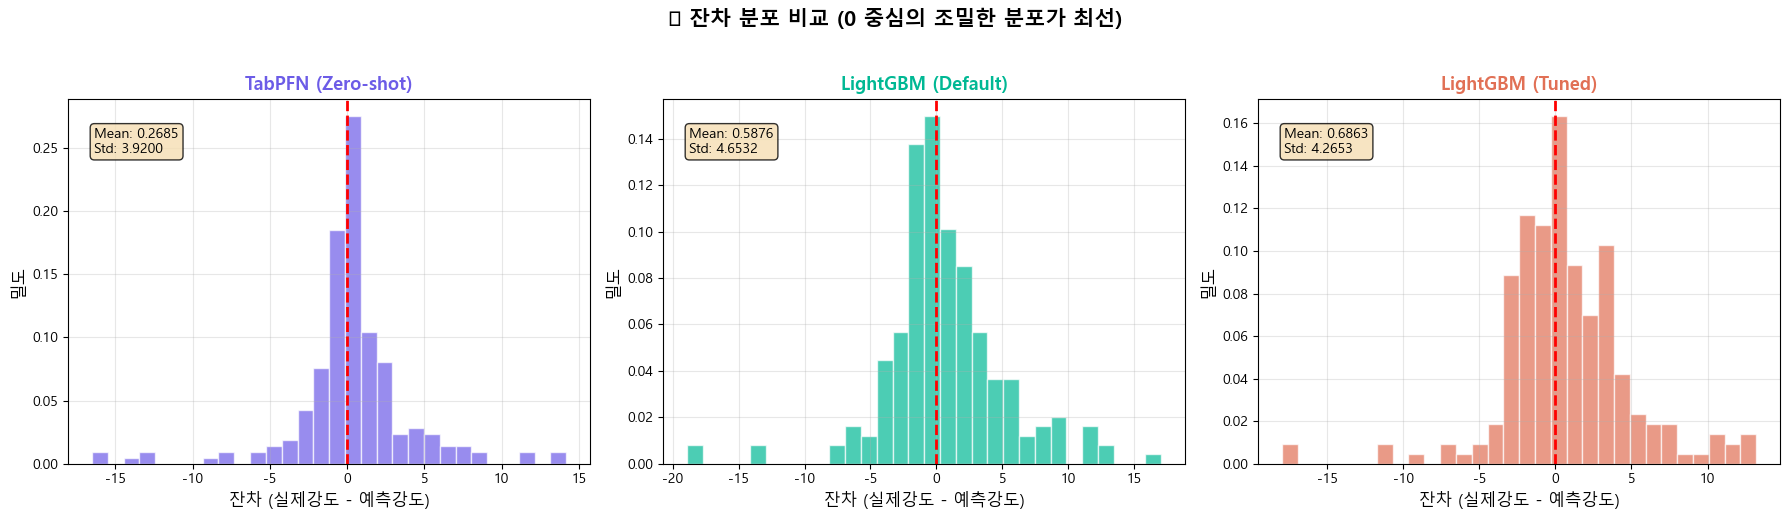

💾 저장: results/figures/06_residual_distribution.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (key, name, y_pred) in zip(axes, models_pred_data):
    residuals = y_test.values - y_pred
    
    ax.hist(residuals, bins=30, color=COLORS[key], alpha=0.7, edgecolor='white', density=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    
    ax.text(0.05, 0.92, f'Mean: {residuals.mean():.4f}\nStd: {residuals.std():.4f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title(name, fontsize=13, fontweight='bold', color=COLORS[key])
    ax.set_xlabel('잔차 (실제강도 - 예측강도)')
    ax.set_ylabel('밀도')

fig.suptitle('📊 잔차 분포 비교 (0 중심의 조밀한 분포가 최선)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_residual_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/06_residual_distribution.png")


### 시각화 - 잔차 vs 예측값 (이분산성 검정)


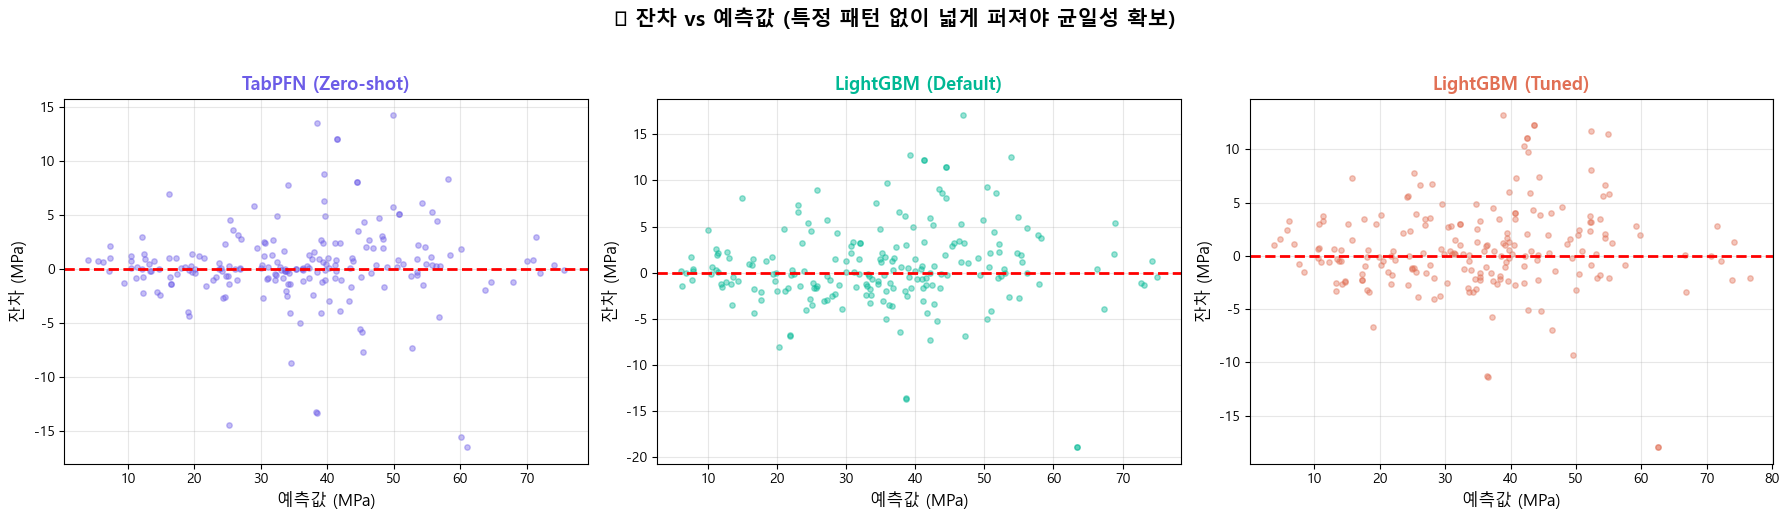

💾 저장: results/figures/07_residual_vs_predicted.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (key, name, y_pred) in zip(axes, models_pred_data):
    residuals = y_test.values - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color=COLORS[key])
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(name, fontsize=13, fontweight='bold', color=COLORS[key])
    ax.set_xlabel('예측값 (MPa)')
    ax.set_ylabel('잔차 (MPa)')

fig.suptitle('🔍 잔차 vs 예측값 (특정 패턴 없이 넓게 퍼져야 균일성 확보)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_residual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/07_residual_vs_predicted.png")


### 시각화 - TabPFN 예측 구간 시각화 (Quantile)


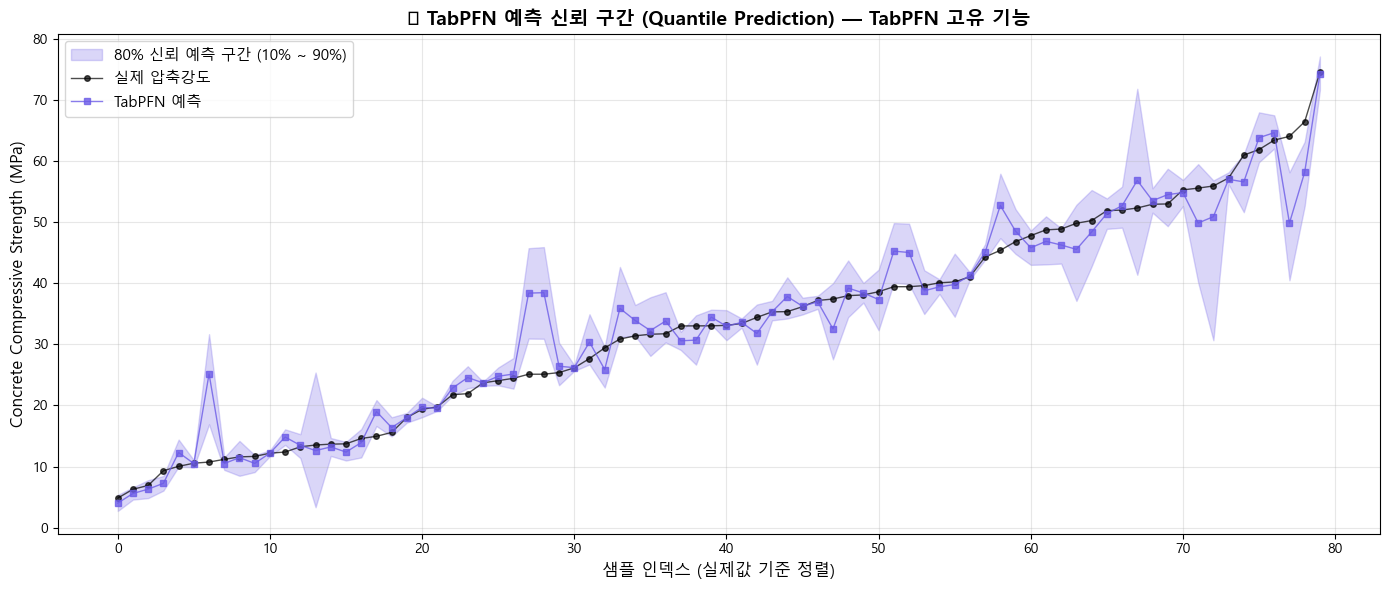

💾 저장: results/figures/08_tabpfn_quantile.png


In [24]:
if has_quantiles:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 80개 샘플만 정렬하여 시각화 (가독성 향상)
    n_show = min(80, len(y_test))
    sort_idx = np.argsort(y_test.values[:n_show])
    
    x_axis = np.arange(n_show)
    y_actual_sorted = y_test.values[:n_show][sort_idx]
    y_pred_sorted = y_pred_tabpfn[:n_show][sort_idx]
    
    # 분위수 값 추출
    # y_quantiles_tabpfn의 차원이 (N, 3) 또는 (3, N)일 수 있음
    if y_quantiles_tabpfn.ndim == 2:
        if y_quantiles_tabpfn.shape[0] == len(y_test):
            q_low = y_quantiles_tabpfn[:n_show, 0][sort_idx]   # 10%
            q_high = y_quantiles_tabpfn[:n_show, -1][sort_idx] # 90%
        else:
            q_low = y_quantiles_tabpfn[0, :n_show][sort_idx]
            q_high = y_quantiles_tabpfn[-1, :n_show][sort_idx]
    else:
        q_low = y_pred_sorted - y_pred_sorted.std()
        q_high = y_pred_sorted + y_pred_sorted.std()
        
    ax.fill_between(x_axis, q_low, q_high, alpha=0.25, color=COLORS['tabpfn'], label='80% 신뢰 예측 구간 (10% ~ 90%)')
    ax.plot(x_axis, y_actual_sorted, 'ko-', markersize=4, linewidth=1, label='실제 압축강도', alpha=0.7)
    ax.plot(x_axis, y_pred_sorted, 's-', color=COLORS['tabpfn'], markersize=4, linewidth=1, label='TabPFN 예측', alpha=0.8)
    
    ax.set_title('🔮 TabPFN 예측 신뢰 구간 (Quantile Prediction) — TabPFN 고유 기능', fontsize=14, fontweight='bold')
    ax.set_xlabel('샘플 인덱스 (실제값 기준 정렬)', fontsize=12)
    ax.set_ylabel('Concrete Compressive Strength (MPa)', fontsize=12)
    ax.legend(loc='upper left', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, '08_tabpfn_quantile.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 저장: results/figures/08_tabpfn_quantile.png")
else:
    print("⏩ 분위수 시각화 건너뜀")


### 성능 지표 바 차트 비교


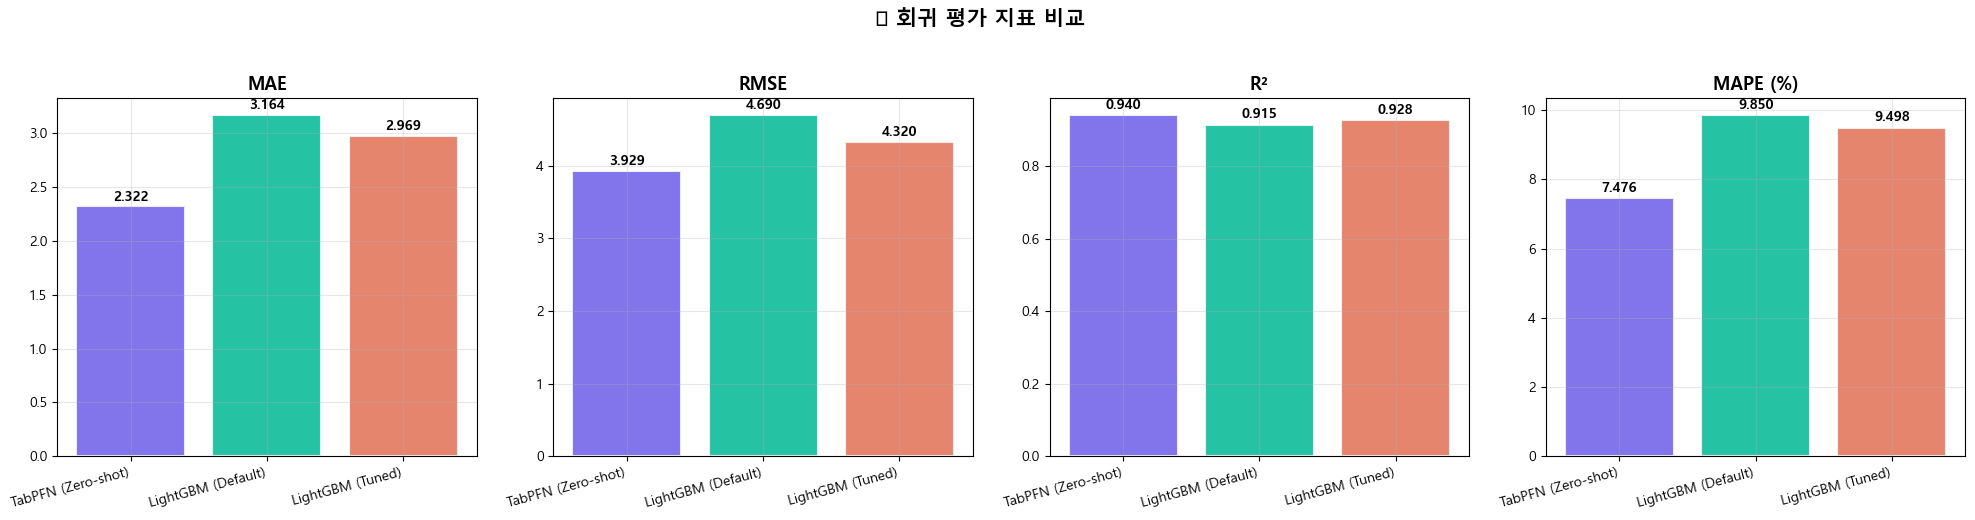

💾 저장: results/figures/09_metrics_comparison.png


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
color_list = [COLORS['tabpfn'], COLORS['lgbm_default'], COLORS['lgbm_tuned']]
model_labels = [MODEL_NAMES[k] for k in ['tabpfn', 'lgbm_default', 'lgbm_tuned']]

for ax, metric in zip(axes, metrics):
    values = df_results[metric].values
    bars = ax.bar(model_labels, values, color=color_list, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # 텍스트 레이블 추가
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(model_labels, rotation=15, ha='right')

fig.suptitle('📊 회귀 평가 지표 비교', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/09_metrics_comparison.png")


### 학습/추론 시간 비교 시각화


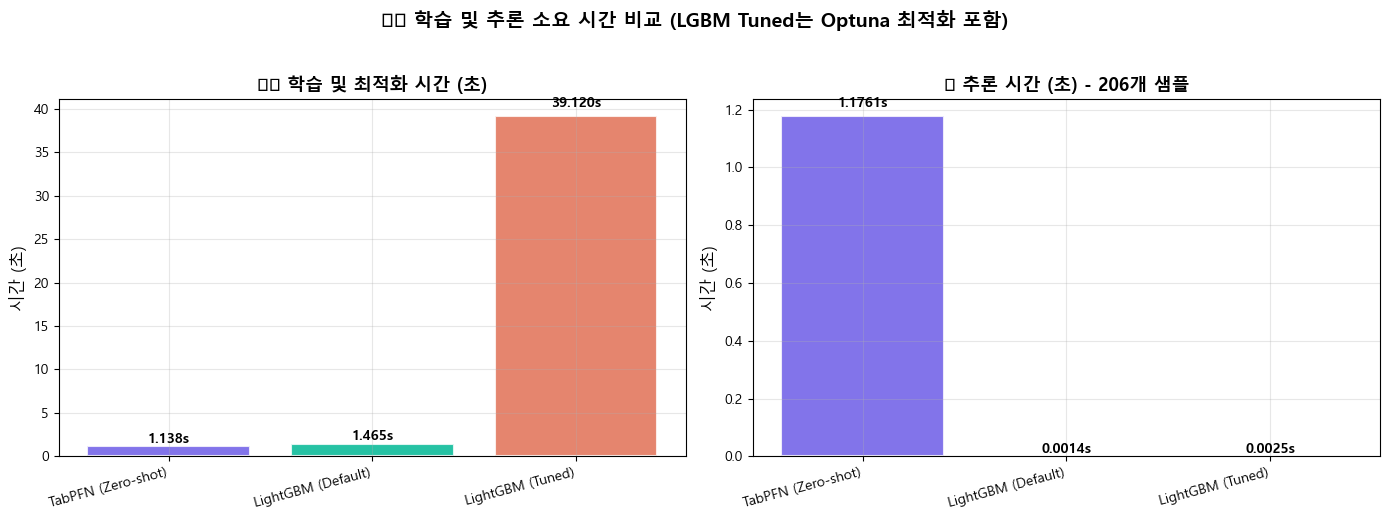

💾 저장: results/figures/10_time_comparison.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_times = [time_fit_tabpfn, time_fit_lgbm_default, time_tuning + time_fit_lgbm_tuned]
pred_times = [time_pred_tabpfn, time_pred_lgbm_default, time_pred_lgbm_tuned]

# 1. 학습 시간 바 차트
bars1 = axes[0].bar(model_labels, fit_times, color=color_list, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, fit_times):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                 f'{val:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('⏱️ 학습 및 최적화 시간 (초)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('시간 (초)')
axes[0].set_xticklabels(model_labels, rotation=15, ha='right')

# 2. 추론 시간 바 차트
bars2 = axes[1].bar(model_labels, pred_times, color=color_list, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, pred_times):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                 f'{val:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('⚡ 추론 시간 (초) - 206개 샘플', fontsize=13, fontweight='bold')
axes[1].set_ylabel('시간 (초)')
axes[1].set_xticklabels(model_labels, rotation=15, ha='right')

fig.suptitle('⏱️ 학습 및 추론 소요 시간 비교 (LGBM Tuned는 Optuna 최적화 포함)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/10_time_comparison.png")


### 피처 중요도 비교


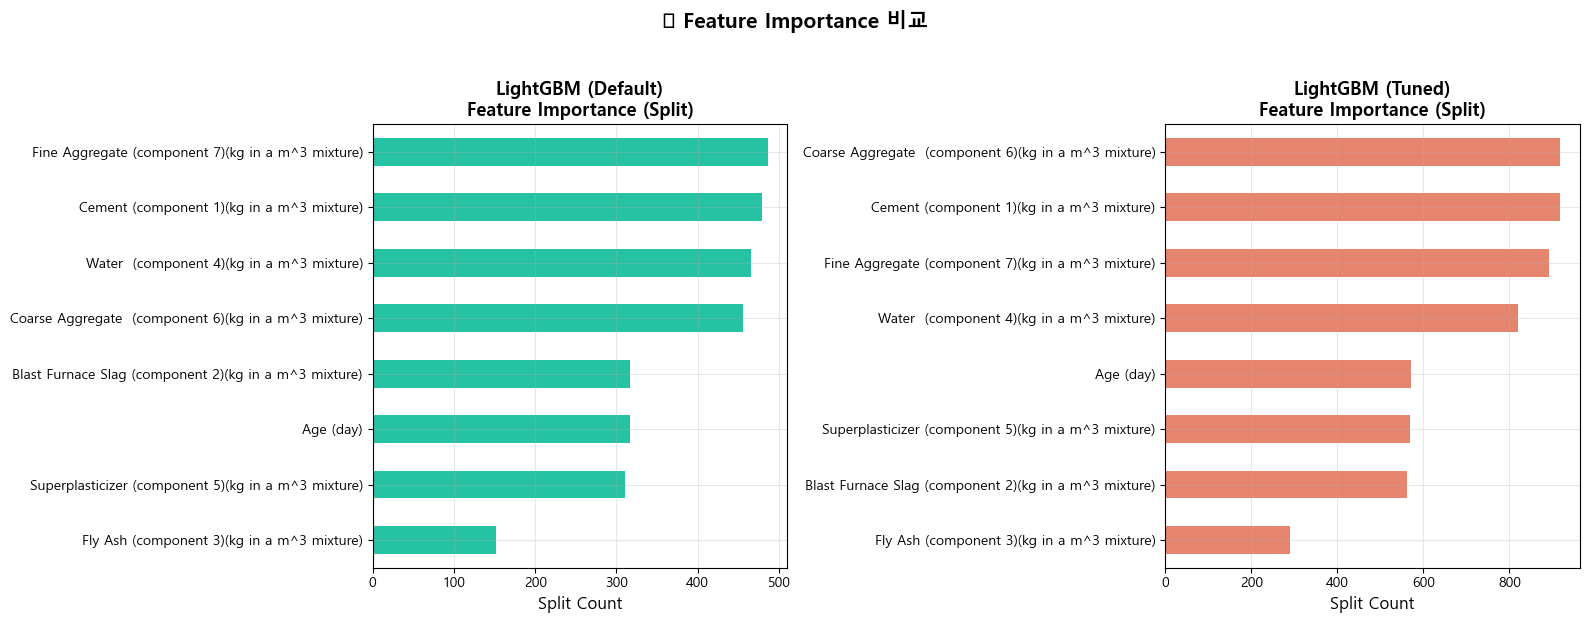

💾 저장: results/figures/11_feature_importance.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LightGBM Default Importance
lgbm_d_imp = pd.Series(
    model_lgbm_default.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
lgbm_d_imp.plot(kind='barh', ax=axes[0], color=COLORS['lgbm_default'], alpha=0.85)
axes[0].set_title('LightGBM (Default)\nFeature Importance (Split)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Split Count')

# LightGBM Tuned Importance
lgbm_t_imp = pd.Series(
    model_lgbm_tuned.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
lgbm_t_imp.plot(kind='barh', ax=axes[1], color=COLORS['lgbm_tuned'], alpha=0.85)
axes[1].set_title('LightGBM (Tuned)\nFeature Importance (Split)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Split Count')

fig.suptitle('🔍 Feature Importance 비교', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/11_feature_importance.png")


### SHAP 분석 (LightGBM Tuned)


🔍 SHAP Feature Importance 산출 중...


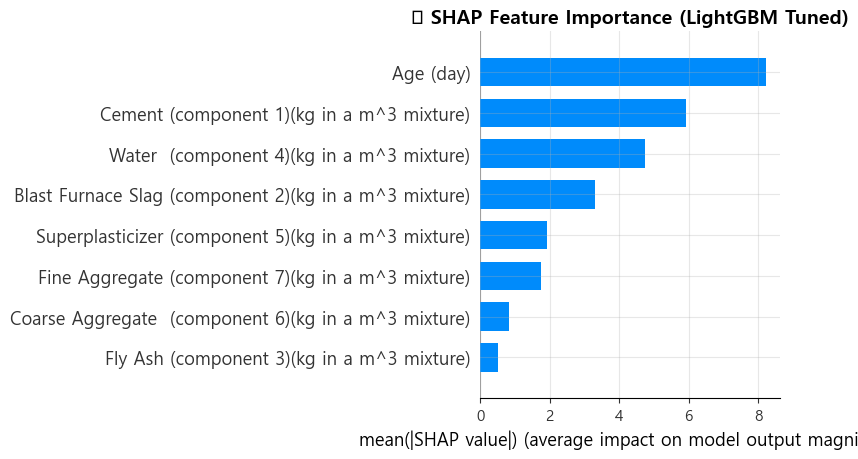

💾 저장: results/figures/12_shap_importance.png


In [28]:
print("🔍 SHAP Feature Importance 산출 중...")
explainer = shap.TreeExplainer(model_lgbm_tuned)
shap_values = explainer.shap_values(X_test)

# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('🔍 SHAP Feature Importance (LightGBM Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '12_shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/12_shap_importance.png")


### SHAP Summary Plot


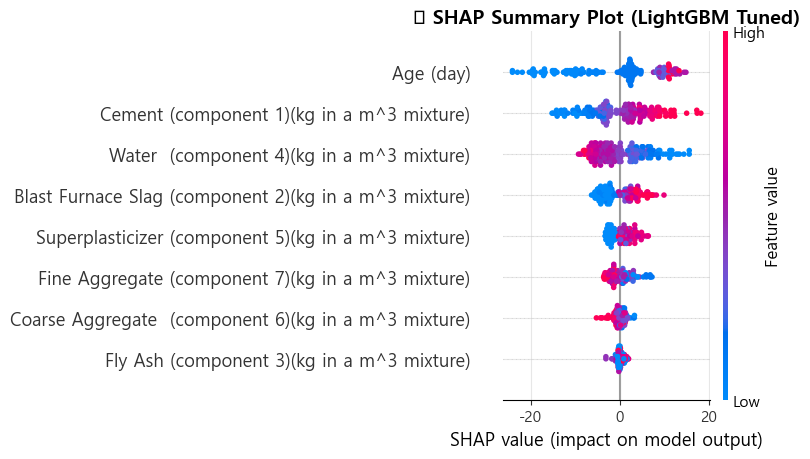

💾 저장: results/figures/13_shap_summary.png


In [29]:
# 상세 Summary Plot (Feature Value 영향 확인)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('🔍 SHAP Summary Plot (LightGBM Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '13_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/13_shap_summary.png")


### 데이터 학습 크기별 RMSE 곡선 (Learning Curve)


📊 학습 데이터 크기에 따른 RMSE 변화 측정 시작...


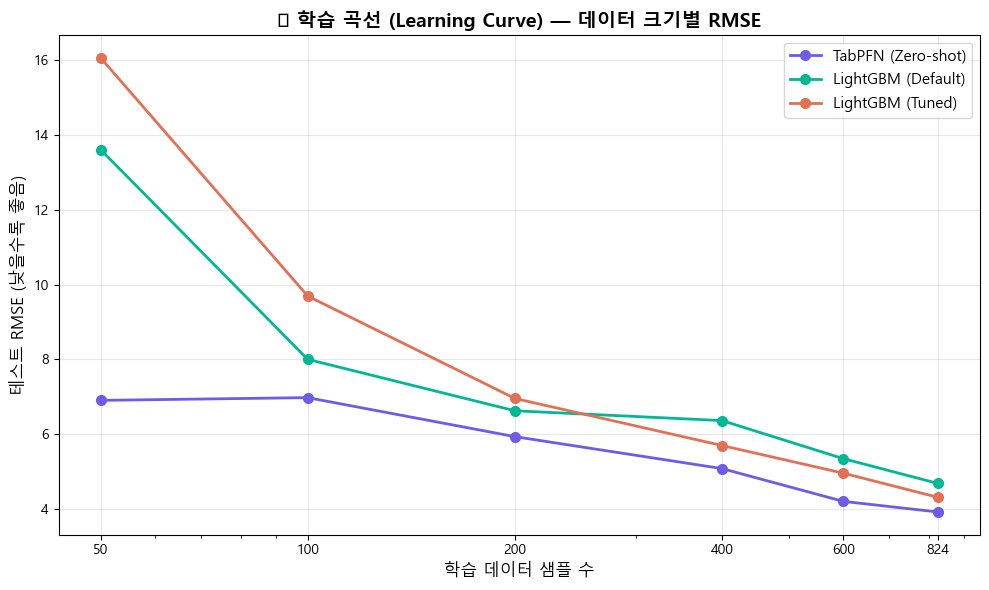

💾 저장: results/figures/14_learning_curve.png


In [30]:
print("📊 학습 데이터 크기에 따른 RMSE 변화 측정 시작...")
train_sizes = [50, 100, 200, 400, 600, len(X_train)]

lc_results = {k: [] for k in ['tabpfn', 'lgbm_default', 'lgbm_tuned']}

for size in train_sizes:
    X_sub = X_train.iloc[:size]
    y_sub = y_train.iloc[:size]
    
    # 1. TabPFN
    m_tab = TabPFNRegressor(device=device)
    m_tab.fit(X_sub, y_sub)
    pred_tab = m_tab.predict(X_test)
    lc_results['tabpfn'].append(np.sqrt(mean_squared_error(y_test, pred_tab)))
    
    # 2. LightGBM Default
    m_lgbm_d = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
    m_lgbm_d.fit(X_sub, y_sub)
    pred_lgbm_d = m_lgbm_d.predict(X_test)
    lc_results['lgbm_default'].append(np.sqrt(mean_squared_error(y_test, pred_lgbm_d)))
    
    # 3. LightGBM Tuned
    m_lgbm_t = lgb.LGBMRegressor(**best_params)
    m_lgbm_t.fit(X_sub, y_sub)
    pred_lgbm_t = m_lgbm_t.predict(X_test)
    lc_results['lgbm_tuned'].append(np.sqrt(mean_squared_error(y_test, pred_lgbm_t)))

fig, ax = plt.subplots(figsize=(10, 6))

for k in ['tabpfn', 'lgbm_default', 'lgbm_tuned']:
    ax.plot(train_sizes, lc_results[k], 'o-', color=COLORS[k], label=MODEL_NAMES[k], linewidth=2, markersize=7)

ax.set_title('📈 학습 곡선 (Learning Curve) — 데이터 크기별 RMSE', fontsize=14, fontweight='bold')
ax.set_xlabel('학습 데이터 샘플 수', fontsize=12)
ax.set_ylabel('테스트 RMSE (낮을수록 좋음)', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(train_sizes)
ax.set_xticklabels([str(s) for s in train_sizes])
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '14_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/14_learning_curve.png")


### 모델 종합 비교 분석 시각화


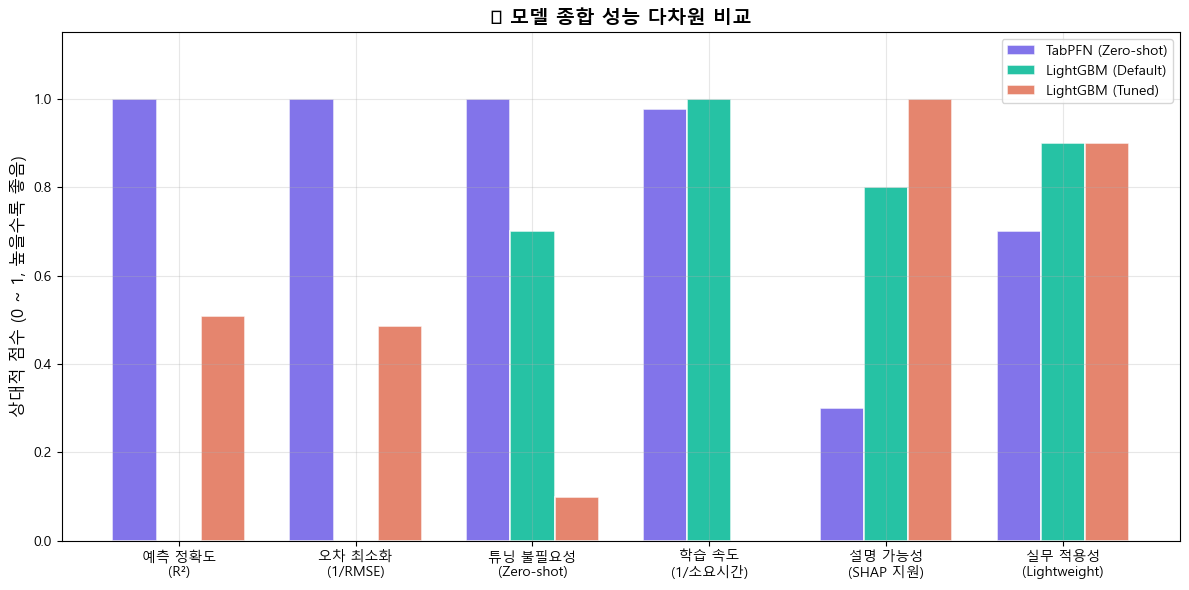

💾 저장: results/figures/15_overall_comparison.png


In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

categories = [
    '예측 정확도\n(R²)', 
    '오차 최소화\n(1/RMSE)', 
    '튜닝 불필요성\n(Zero-shot)', 
    '학습 속도\n(1/소요시간)', 
    '설명 가능성\n(SHAP 지원)', 
    '실무 적용성\n(Lightweight)'
]

r2_vals = df_results['R²'].values
rmse_vals = df_results['RMSE'].values
total_times = [
    time_fit_tabpfn + time_pred_tabpfn,
    time_fit_lgbm_default + time_pred_lgbm_default,
    time_tuning + time_fit_lgbm_tuned + time_pred_lgbm_tuned
]

# 점수 정규화 (0 ~ 1)
r2_norm = (r2_vals - r2_vals.min()) / (r2_vals.max() - r2_vals.min() + 1e-8)
rmse_norm = 1 - (rmse_vals - rmse_vals.min()) / (rmse_vals.max() - rmse_vals.min() + 1e-8)
time_norm = 1 - (np.array(total_times) - min(total_times)) / (max(total_times) - min(total_times) + 1e-8)

scores = {
    'tabpfn': [r2_norm[0], rmse_norm[0], 1.0, time_norm[0], 0.3, 0.7],       # TabPFN은 SHAP 지원 한계 있음
    'lgbm_default': [r2_norm[1], rmse_norm[1], 0.7, time_norm[1], 0.8, 0.9], # 빠름, SHAP 지원 좋음
    'lgbm_tuned': [r2_norm[2], rmse_norm[2], 0.1, time_norm[2], 1.0, 0.9],   # 튜닝에 시간 걸림
}

x = np.arange(len(categories))
width = 0.25

for i, k in enumerate(['tabpfn', 'lgbm_default', 'lgbm_tuned']):
    ax.bar(x + i * width, scores[k], width, label=MODEL_NAMES[k], color=COLORS[k], alpha=0.85, edgecolor='white', linewidth=1.2)

ax.set_xticks(x + width)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('상대적 점수 (0 ~ 1, 높을수록 좋음)')
ax.set_title('🏆 모델 종합 성능 다차원 비교', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '15_overall_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 저장: results/figures/15_overall_comparison.png")


### 모델 간 통계적 유의성 검정 (Paired t-test)


In [32]:
print("=" * 60)
print("📊 모델 간 통계적 성능 차이 검정 (Paired t-test)")
print("=" * 60)
from scipy import stats

# 1. 절대 오차 (Absolute Error) 계산
ae_tabpfn = np.abs(y_test.values - y_pred_tabpfn)
ae_lgbm_tuned = np.abs(y_test.values - y_pred_lgbm_tuned)

# 2. 제곱 오차 (Squared Error) 계산
se_tabpfn = (y_test.values - y_pred_tabpfn) ** 2
se_lgbm_tuned = (y_test.values - y_pred_lgbm_tuned) ** 2

# 대응표본 t-검정 (Paired t-test) 수행
t_stat_ae, p_val_ae = stats.ttest_rel(ae_tabpfn, ae_lgbm_tuned)
t_stat_se, p_val_se = stats.ttest_rel(se_tabpfn, se_lgbm_tuned)

print("📌 1. 절대 오차 (Absolute Error) 비교:")
print(f"  - TabPFN 평균 절대오차 : {ae_tabpfn.mean():.4f} MPa")
print(f"  - LGBM Tuned 평균 절대오차: {ae_lgbm_tuned.mean():.4f} MPa")
print(f"  - t-statistic: {t_stat_ae:.6f}")
print(f"  - p-value    : {p_val_ae:.6e}")
if p_val_ae < 0.05:
    print("  => 결과: 두 모델의 절대 오차 차이는 통계적으로 매우 유의미합니다. (TabPFN 우세)")
else:
    print("  => 결과: 두 모델의 절대 오차 차이는 통계적으로 유의미하지 않습니다.")
print()

print("📌 2. 제곱 오차 (Squared Error) 비교 (MSE/RMSE의 기초 오차):")
print(f"  - TabPFN 평균 제곱오차 : {se_tabpfn.mean():.4f}")
print(f"  - LGBM Tuned 평균 제곱오차: {se_lgbm_tuned.mean():.4f}")
print(f"  - t-statistic: {t_stat_se:.6f}")
print(f"  - p-value    : {p_val_se:.6e}")
if p_val_se < 0.05:
    print("  => 결과: 두 모델의 제곱 오차 차이는 통계적으로 유의미합니다.")
else:
    print("  => 결과: 두 모델의 제곱 오차 차이는 통계적으로 유의미하지 않습니다. (p > 0.05)")


📊 모델 간 통계적 성능 차이 검정 (Paired t-test)
📌 1. 절대 오차 (Absolute Error) 비교:
  - TabPFN 평균 절대오차 : 2.3218 MPa
  - LGBM Tuned 평균 절대오차: 2.9687 MPa
  - t-statistic: -4.390964
  - p-value    : 1.807149e-05
  => 결과: 두 모델의 절대 오차 차이는 통계적으로 매우 유의미합니다. (TabPFN 우세)

📌 2. 제곱 오차 (Squared Error) 비교 (MSE/RMSE의 기초 오차):
  - TabPFN 평균 제곱오차 : 15.4387
  - LGBM Tuned 평균 제곱오차: 18.6638
  - t-statistic: -1.774279
  - p-value    : 7.750131e-02
  => 결과: 두 모델의 제곱 오차 차이는 통계적으로 유의미하지 않습니다. (p > 0.05)


### 최종 결론 리포트 출력


In [33]:
print("=" * 80)
print("📝 CONCRETE COMPRESSIVE STRENGTH 분석 최종 요약")
print("=" * 80)
print(f"1. 최적의 R² 예측 성능 모델: {best_r2_model} (R² = {df_results.loc[best_r2_model, 'R²']:.4f})")
print(f"2. 가장 낮은 오차(RMSE): {best_rmse_model} (RMSE = {df_results.loc[best_rmse_model, 'RMSE']:.4f})")
print(f"3. 시간 효율성:")
print(f"   - TabPFN (Zero-shot)  : 학습/추론 {time_fit_tabpfn + time_pred_tabpfn:.3f}초 (하이퍼파라미터 튜닝 없이 고성능 확보)")
print(f"   - LightGBM (Default)  : 학습/추론 {time_fit_lgbm_default + time_pred_lgbm_default:.3f}초 (가장 신속함)")
print(f"   - LightGBM (Tuned)    : Optuna 튜닝 포함 총 {time_tuning + time_fit_lgbm_tuned + time_pred_lgbm_tuned:.1f}초")
print("=" * 80)
print("✅ 분석 프로세스가 성공적으로 완료되었습니다.")


📝 CONCRETE COMPRESSIVE STRENGTH 분석 최종 요약
1. 최적의 R² 예측 성능 모델: TabPFN (Zero-shot) (R² = 0.9401)
2. 가장 낮은 오차(RMSE): TabPFN (Zero-shot) (RMSE = 3.9292)
3. 시간 효율성:
   - TabPFN (Zero-shot)  : 학습/추론 2.314초 (하이퍼파라미터 튜닝 없이 고성능 확보)
   - LightGBM (Default)  : 학습/추론 1.466초 (가장 신속함)
   - LightGBM (Tuned)    : Optuna 튜닝 포함 총 39.1초
✅ 분석 프로세스가 성공적으로 완료되었습니다.
